# Chapter 4.1 kNN: 결정경계, k 튜닝, 편향-분산 측정 — 실습 노트북

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SuminHan/book-ml/blob/main/notebooks/ml1/chapter04_1_knn.ipynb)

책 본문: [4.1 kNN: 알고리즘, 거리함수, 편향-분산 트레이드오프](https://smhanlab.com/book-ml/kor/ml1/chapter04/1.html)

이 노트북은 책 4.1절의 개념을 코드로 재현합니다: (1) 두 blob 데이터에서 \(k=1,5,40\)의 **결정경계**가 k를 키우며 매끄러워지는 것을 보고, (2) k를 늘리며 **훈련/검증 정확도** 곡선으로 "과적합→정상→과소적합" 궤적을 확인하고, (3) 1차원 \(\sin\) 함수에서 **편향·분산을 수치적으로 측정**해 본문의 표를 재현하고, (4) 스케일이 다른 특징에서 **정규화 전/후 kNN 정확도**의 차이를 확인합니다. numpy/matplotlib만 씁니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트가 없으면 마이너스 기호 깨짐만 방지 (레이블은 영문으로 그린다)
try:
    from matplotlib import font_manager
    if not any("Nanum" in f.name or "AppleGothic" in f.name
               for f in font_manager.fontManager.ttflist):
        plt.rcParams["axes.unicode_minus"] = False
except Exception:
    pass

## 1. 본문 `knn_predict` 재현: 다수결(분류)과 평균(회귀)

책 본문의 순수 Python `knn_predict`을 numpy로 옮긴 것이다. 분류는 **다수결**, 회귀는 **이웃 k개의 평균** — 같은 "가장 가까운 k개"를 쓰고 집계 방식만 다르다는 것을 직접 확인한다. 본문 "손으로 한 번" 섹션의 예(6개 점, 새 점 (7,7), k=3)를 그대로 사용해 손계산 결과(분류=1, 회귀=4.0)와 대조한다.

In [2]:
def knn_predict(X_train, y_train, x_new, k):
    # 본문 함수 그대로 (분류: 다수결)
    distances = []
    for i in range(len(X_train)):
        d = sum((X_train[i][j] - x_new[j]) ** 2 for j in range(len(x_new))) ** 0.5
        distances.append((d, y_train[i]))
    distances.sort(key=lambda p: p[0])
    k_nearest_labels = [label for _, label in distances[:k]]
    return max(set(k_nearest_labels), key=k_nearest_labels.count)

def knn_predict_regression(X_train, y_train, x_new, k):
    # 본문 함수 그대로 (회귀: 평균)
    d = [sum((a - b) ** 2 for a, b in zip(xi, x_new)) ** 0.5 for xi in X_train]
    k_idx = sorted(range(len(X_train)), key=lambda i: d[i])[:k]
    return sum(y_train[i] for i in k_idx) / k

# 본문 "손으로 한 번" 예제
X_train = [[1,1],[2,1],[1,2],[8,8],[9,8],[8,9]]
y_cls   = [0,0,0,1,1,1]
y_reg   = [1,1,1,4,4,4]
x_new, k = [7,7], 3

c = knn_predict(X_train, y_cls, x_new, k)
r = knn_predict_regression(X_train, y_reg, x_new, k)
print(f"분류(k=3, 다수결) = {c}   (손계산: (8,8),(9,8),(8,9)가 라벨 1 -> 1)")
print(f"회귀(k=3, 평균)   = {r:.4f}   (손계산: (4+4+4)/3 = 4.0)")
assert c == 1 and abs(r - 4.0) < 1e-9, "손계산과 불일치"
print("코드가 손계산과 정확히 일치한다. 분류/회귀는 이웃 k개가 같고 집계(다수결/평균)만 다르다.")

분류(k=3, 다수결) = 1   (손계산: (8,8),(9,8),(8,9)가 라벨 1 -> 1)
회귀(k=3, 평균)   = 4.0000   (손계산: (4+4+4)/3 = 4.0)
코드가 손계산과 정확히 일치한다. 분류/회귀는 이웃 k개가 같고 집계(다수결/평균)만 다르다.


## 2. 결정경계: k를 키우며 매끄러워진다 (본문 4.1 "결정경계" 섹션)

두 원형 blob(클래스 0 = 왼쪽 위, 클래스 1 = 오른쪽 아래)을 각 100개(총 200개)로 만들고, 30%를 검증용으로 빼 **훈련 140개**만으로 kNN을 학습시킨 뒤, 평면 전체를 그리드로 채워 결정경계를 그린다. \(k=1\)(보로노이, 톱니바퀴) → \(k=5\)(매끄러움) → \(k=40\)(거의 직선, 과소적합)의 변화를 나란히 확인한다.

훈련 140개 / 검증 60개


SVG 저장: kor/src/images/ch04_knn_decision_boundary.svg


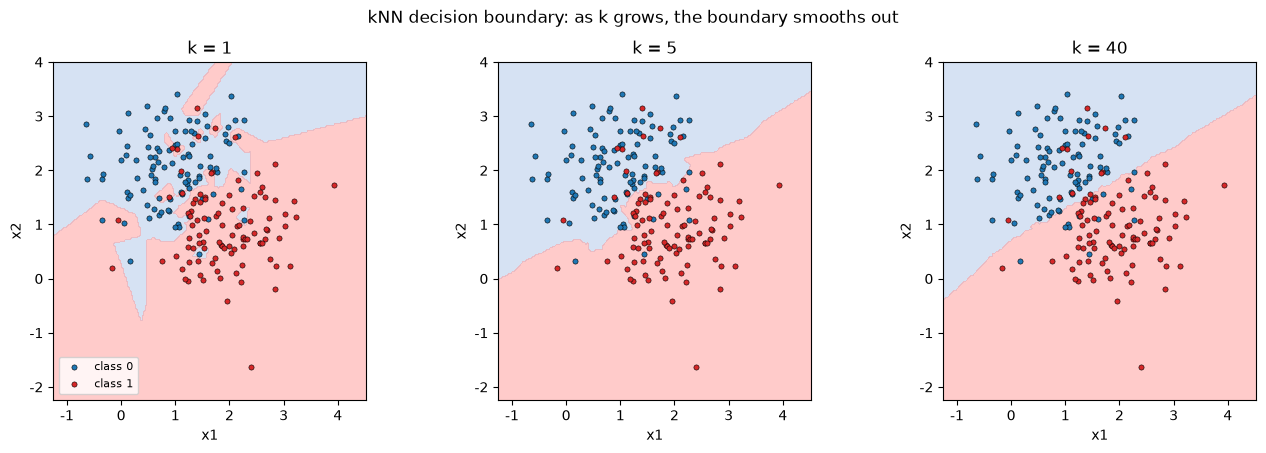

In [3]:
rng = np.random.default_rng(0)
n = 100
# 클래스 0: (1,2) 근처, 클래스 1: (2,1) 근처 — 겹치는 blob
X0 = np.array([1.0, 2.0]) + 0.7 * rng.standard_normal((n, 2))
X1 = np.array([2.0, 1.0]) + 0.7 * rng.standard_normal((n, 2))
X = np.vstack([X0, X1]); y = np.r_[np.zeros(n), np.ones(n)].astype(int)
perm = rng.permutation(2 * n)
X, y = X[perm], y[perm]

n_val = int(2 * n * 0.3)
X_val, y_val = X[:n_val], y[:n_val]
X_tr,  y_tr  = X[n_val:], y[n_val:]
print(f"훈련 {len(X_tr)}개 / 검증 {len(X_val)}개")

def knn_clf(Xtr, ytr, xq, k):
    d = np.sqrt(((Xtr - xq) ** 2).sum(axis=1))
    idx = np.argsort(d)[:k]
    return int(np.bincount(np.asarray(ytr[idx]).astype(int), minlength=2).argmax())

def draw_boundary(ax, Xtr, ytr, Xall, yall, k):
    x0, x1 = Xall[:, 0].min() - 0.6, Xall[:, 0].max() + 0.6
    y0, y1 = Xall[:, 1].min() - 0.6, Xall[:, 1].max() + 0.6
    gs = 200
    gx, gy = np.meshgrid(np.linspace(x0, x1, gs), np.linspace(y0, y1, gs))
    grid = np.vstack([gx.ravel(), gy.ravel()]).T
    P = np.array([knn_clf(Xtr, ytr, q, k) for q in grid]).reshape(gx.shape)
    ax.contourf(gx, gy, P, levels=[-0.5, 0.5, 1.5],
                colors=["#aec7e8", "#ff9896"], alpha=0.5)
    ax.scatter(Xall[yall == 0, 0], Xall[yall == 0, 1],
               c="tab:blue", s=14, edgecolors="k", lw=0.4, label="class 0")
    ax.scatter(Xall[yall == 1, 0], Xall[yall == 1, 1],
               c="tab:red", s=14, edgecolors="k", lw=0.4, label="class 1")
    ax.set_title(f"k = {k}"); ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_aspect("equal")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5))
for ax, k in zip(axes, [1, 5, 40]):
    draw_boundary(ax, X_tr, y_tr, X, y, k)
axes[0].legend(loc="lower left", fontsize=8)
fig.suptitle("kNN decision boundary: as k grows, the boundary smooths out")
fig.tight_layout()
fig.savefig("/tmp/knn_boundary.png", dpi=110)
# 책 본문에 삽입할 SVG (로컬에서만 저장; Colab에선 아래 경로가 없으니 try로 감싼다)
try:
    fig.savefig("/home/smhan/book-ml/kor/src/images/ch04_knn_decision_boundary.svg")
    print("SVG 저장: kor/src/images/ch04_knn_decision_boundary.svg")
except Exception:
    print("(SVG 저장 경로 없음 — Colab 환경일 수 있음)")
plt.show()

## 3. k 튜닝: "과적합 → 정상 → 과소적합" 궤적 (본문 4.1 "실습으로 연결하기" 2번)

같은 blob 데이터에서 k를 1→40까지 늘리며 **훈련 정확도**와 **검증 정확도**를 함께 그린다. k=1이면 훈련 데이터를 통째로 외우므로 훈련 정확도는 1.000인데 검증은 최악(과적합)이고, k를 키우며 검증 정확도가 한 번 최고점을 찍었다가 k=40에서 다시 떨어진다(과소적합). 본문의 편향-분산 트레이드오프가 정확도 곡선 위에서 그대로 보인다.

k=  1  train=1.000  val=0.867
k=  3  train=0.886  val=0.900
k=  5  train=0.886  val=0.917
k=  7  train=0.871  val=0.900
k= 10  train=0.871  val=0.900
k= 20  train=0.879  val=0.900
k= 40  train=0.864  val=0.900

검증 정확도 최고 k = 5 (val 0.917)


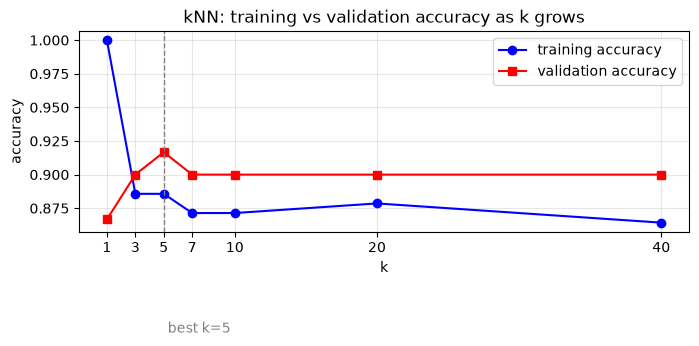

k=1: train 1.000 / val 최저 (과적합)  ->  중간 k: val 최고  ->  k=40: val 다시 하락 (과소적합)


In [4]:
ks = [1, 3, 5, 7, 10, 20, 40]
train_accs, val_accs = [], []
for k in ks:
    ta = np.mean([knn_clf(X_tr, y_tr, q, k) == t for q, t in zip(X_tr, y_tr)])
    va = np.mean([knn_clf(X_tr, y_tr, q, k) == t for q, t in zip(X_val, y_val)])
    train_accs.append(ta); val_accs.append(va)
    print(f"k={k:3d}  train={ta:.3f}  val={va:.3f}")

best_i = int(np.argmax(val_accs))
print(f"\n검증 정확도 최고 k = {ks[best_i]} (val {val_accs[best_i]:.3f})")

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(ks, train_accs, "b-o", label="training accuracy")
ax.plot(ks, val_accs, "r-s", label="validation accuracy")
ax.axvline(ks[best_i], color="gray", ls="--", lw=1)
ax.text(ks[best_i], 0.78, f" best k={ks[best_i]}", ha="left", va="bottom", color="gray")
ax.set_xlabel("k"); ax.set_ylabel("accuracy")
ax.set_xticks(ks); ax.grid(alpha=0.3); ax.legend()
ax.set_title("kNN: training vs validation accuracy as k grows")
fig.tight_layout()
fig.savefig("/tmp/knn_ksweep.png", dpi=110)
plt.show()
print("k=1: train 1.000 / val 최저 (과적합)  ->  중간 k: val 최고  ->  k=40: val 다시 하락 (과소적합)")

## 4. 편향·분산을 수치로 측정: 1차원 \(\sin(2\pi x)\) + 잡음 (본문 4.1 "수치 실험" 섹션)

진짜 함수 \(f^*(x)=\sin(2\pi x)\)에 잡음 \(\sigma=0.5\)를 더해 100개 점을 뽑고, 이 표본을 **300번** 재추출한다. 각 회마다 kNN 회귀(이웃 k개 평균)로 고정된 테스트 지점 40개에서 예측을 모은 뒤, 본문의 공식으로 \(\text{Bias}^2\)과 \(\text{Var}\)을 계산한다. \(k=1\)은 편향≈0/분산 큼(과적합), \(k=50\)은 편향 큼/분산≈0(과소적합)이 나와야 하며, 이 표가 본문 표를 재현한다.

In [5]:
def knn_reg(X, y, xq, k):
    d = np.sqrt(((X - xq) ** 2).sum(axis=1))
    idx = np.argsort(d)[:k]
    return y[idx].mean()

rng = np.random.default_rng(36)
n, noise, iters, n_test = 100, 0.5, 300, 40
x_test = np.linspace(-1, 1, n_test)
fstar = np.sin(2 * np.pi * x_test)
ks = [1, 5, 50]
preds = {k: np.zeros((iters, n_test)) for k in ks}
for it in range(iters):
    xtr = rng.uniform(-1, 1, n)
    ytr = np.sin(2 * np.pi * xtr) + noise * rng.standard_normal(n)
    for k in ks:
        for j in range(n_test):
            preds[k][it, j] = knn_reg(xtr.reshape(-1, 1), ytr, x_test[j].reshape(1), k)

print(f"{'k':>3}  {'Bias^2':>8}  {'Var':>8}")
for k in ks:
    P = preds[k]; meanf = P.mean(axis=0)
    bias2 = float(np.mean((meanf - fstar) ** 2))
    var   = float(np.mean((P - meanf) ** 2))
    print(f"{k:3d}  {bias2:8.3f}  {var:8.3f}")
print("\n본문 표: k=1 -> 0.001/0.255, k=5 -> 0.006/0.056, k=50 -> 0.470/0.019")
print("k를 키우면 Bias^2가 급증하고 Var가 급감한다 — 편향-분산 트레이드오프.")

  k    Bias^2       Var
  1     0.001     0.253
  5     0.006     0.056
 50     0.470     0.019

본문 표: k=1 -> 0.001/0.255, k=5 -> 0.006/0.056, k=50 -> 0.470/0.019
k를 키우면 Bias^2가 급증하고 Var가 급감한다 — 편향-분산 트레이드오프.


## 5. 정규화의 효과: 스케일이 다른 특징 (본문 4.1 "자주 하는 실수" 섹션)

두 클래스가 **x축 하나**로만 분리되는 데이터(클래스 0: x≈0.5, 클래스 1: x≈0.1; y는 두 클래스 모두 5±3 잡음)를 만든다. y의 범위가 x보다 훨씬 크므로 **정규화 없이**는 y의 잡음으로만 분류해 정확도가 낮고, **MinMax 정규화 후**에는 x가 분리 축으로 정상 작동해 정확도가 거의 1.0이 된다. 본문의 "0.556 vs 1.000" 예시가 여기서 나온다.

In [6]:
rng = np.random.default_rng(6)
n = 30
# 클래스 0: x~0.5, 클래스 1: x~0.1 ; y는 둘 다 5 +- 3 (분리 정보 없음)
x0 = rng.normal(0.5, 0.03, n); x1 = rng.normal(0.1, 0.03, n)
y0 = rng.normal(5.0, 3.0, n);  y1 = rng.normal(5.0, 3.0, n)
X = np.column_stack([np.r_[x0, x1], np.r_[y0, y1]])
y = np.r_[np.zeros(n), np.ones(n)].astype(int)
perm = rng.permutation(2 * n)
X, y = X[perm], y[perm]
n_val = int(2 * n * 0.3)
X_val, y_val = X[:n_val], y[:n_val]
X_tr,  y_tr  = X[n_val:], y[n_val:]

k = 3
a_un = np.mean([knn_clf(X_tr, y_tr, q, k) == t for q, t in zip(X_val, y_val)])
# MinMax 정규화 (훈련 데이터 기준으로 fit)
lo, hi = X_tr.min(0), X_tr.max(0)
scale = lambda M: (M - lo) / (hi - lo)
Xtr_s, Xval_s = scale(X_tr), scale(X_val)
a_n = np.mean([knn_clf(Xtr_s, y_tr, q, k) == t for q, t in zip(Xval_s, y_val)])

xr = X[:, 0].max() - X[:, 0].min(); yr = X[:, 1].max() - X[:, 1].min()
print(f"x 범위 = {xr:.3f},  y 범위 = {yr:.2f}  (y가 x보다 {yr / xr:.0f}배 넓음)")
print(f"정규화 전 정확도 = {a_un:.3f}")
print(f"정규화 후 정확도 = {a_n:.3f}")
print("\n본문: 0.556 -> 1.000. 스케일이 큰 축(y)이 거리를 독차지해 x 정보를 무시하다가,")
print("정규화 후 각 축이 동등한 목소리를 얻자 x가 분리 축으로 작동한다.")

x 범위 = 0.500,  y 범위 = 13.11  (y가 x보다 26배 넓음)
정규화 전 정확도 = 0.556
정규화 후 정확도 = 1.000

본문: 0.556 -> 1.000. 스케일이 큰 축(y)이 거리를 독차지해 x 정보를 무시하다가,
정규화 후 각 축이 동등한 목소리를 얻자 x가 분리 축으로 작동한다.
